# Hellinger Distance for Exponential Family Distributions

This notebook demonstrates that the Hellinger distance is a robust error metric
for GIG and GH parameter estimation — even when relative errors of individual
parameters are enormous, the Hellinger distance remains small.

We replicate the key numerical experiments from [Shi2016], Tables 1–3:

1. **Table 1**: GIG MLE — large relative error in $a$ (or $\psi$), tiny $H^2$
2. **Table 2**: GH M-step roundtrip — $\mu, \gamma, \Sigma$ recover at machine epsilon,
   GIG parameters may not, yet $H^2$ stays small
3. **Table 3**: Full GH EM — sweep $p \in \{-10, \ldots, 10\}$, relative errors
   vs squared Hellinger distance

**Parametrization mapping** (thesis $\leftrightarrow$ normix):

| Thesis | normix | Role |
|--------|--------|------|
| $\lambda$ | $p$ | shape |
| $\chi$ | $b$ | coefficient of $y^{-1}$ |
| $\psi$ | $a$ | coefficient of $y$ |

In [ ]:
import numpy as np
import jax, jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
jax.config.update("jax_enable_x64", True)

from normix import (
    GIG, GeneralizedHyperbolic, JointGeneralizedHyperbolic,
    squared_hellinger, kl_divergence, squared_hellinger_from_psi,
    BatchEMFitter,
)
from normix.mixtures.joint import JointNormalMixture
from normix.utils.plotting import FIG_W, FIG_H

np.set_printoptions(precision=6, suppress=False)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
%matplotlib inline

def rel_err(true, est):
    return abs(est - true) / max(abs(true), 1e-300)

def vec_rel_err(v_true, v_est):
    return float(jnp.linalg.norm(v_est - v_true) /
                 jnp.maximum(jnp.linalg.norm(v_true), 1e-300))

## Table 1: Relative Errors of the GIG Parameters

Generate samples from $\mathrm{GIG}(p=-10, a=10^{-5}, b=1)$ and fit via MLE.
The log-likelihood is very flat w.r.t. $a$ when $|p|$ is large and $a \approx 0$
(near the Inverse-Gamma limit), so the MLE of $a$ can be wildly off.
Yet the Hellinger distance stays tiny.

In [2]:
p_true, a_true, b_true = -10.0, 1e-5, 1.0
gig_true = GIG(p=p_true, a=a_true, b=b_true)

Y = gig_true.rvs(10000, seed=42)
gig_fitted = GIG.fit_mle(Y, verbose=1)

p_hat = float(gig_fitted.p)
a_hat = float(gig_fitted.a)
b_hat = float(gig_fitted.b)

h2 = float(squared_hellinger(gig_true, gig_fitted))

table1 = pd.DataFrame({
    'Parameter': ['p (lambda)', 'b (chi)', 'a (psi)'],
    'True': [p_true, b_true, a_true],
    'Estimated': [p_hat, b_hat, a_hat],
    'Relative Error': [
        rel_err(p_true, p_hat),
        rel_err(b_true, b_hat),
        rel_err(a_true, a_hat),
    ],
})

print('Table 1: Relative errors of the GIG parameters')
print('=' * 60)
print(table1.to_string(index=False))
print(f'\nSquared Hellinger distance: {h2:.4e}')
print(f'Hellinger distance:         {np.sqrt(h2):.4e}')

Bregman multistart [cpu/lbfgs, 15 starts]: converged (0.072s), |grad|=3.94e-04
Table 1: Relative errors of the GIG parameters
 Parameter      True  Estimated  Relative Error
p (lambda) -10.00000  -9.963007        0.003699
   b (chi)   1.00000   0.998141        0.001859
   a (psi)   0.00001   0.000000        1.000000

Squared Hellinger distance: 4.7137e-06
Hellinger distance:         2.1711e-03


### Log-likelihood Landscape

Plot the GIG log-likelihood as a function of $a$ (with $p$ and $b$ fixed at the true values).
The curve is extremely flat, explaining why MLE of $a$ is unreliable.

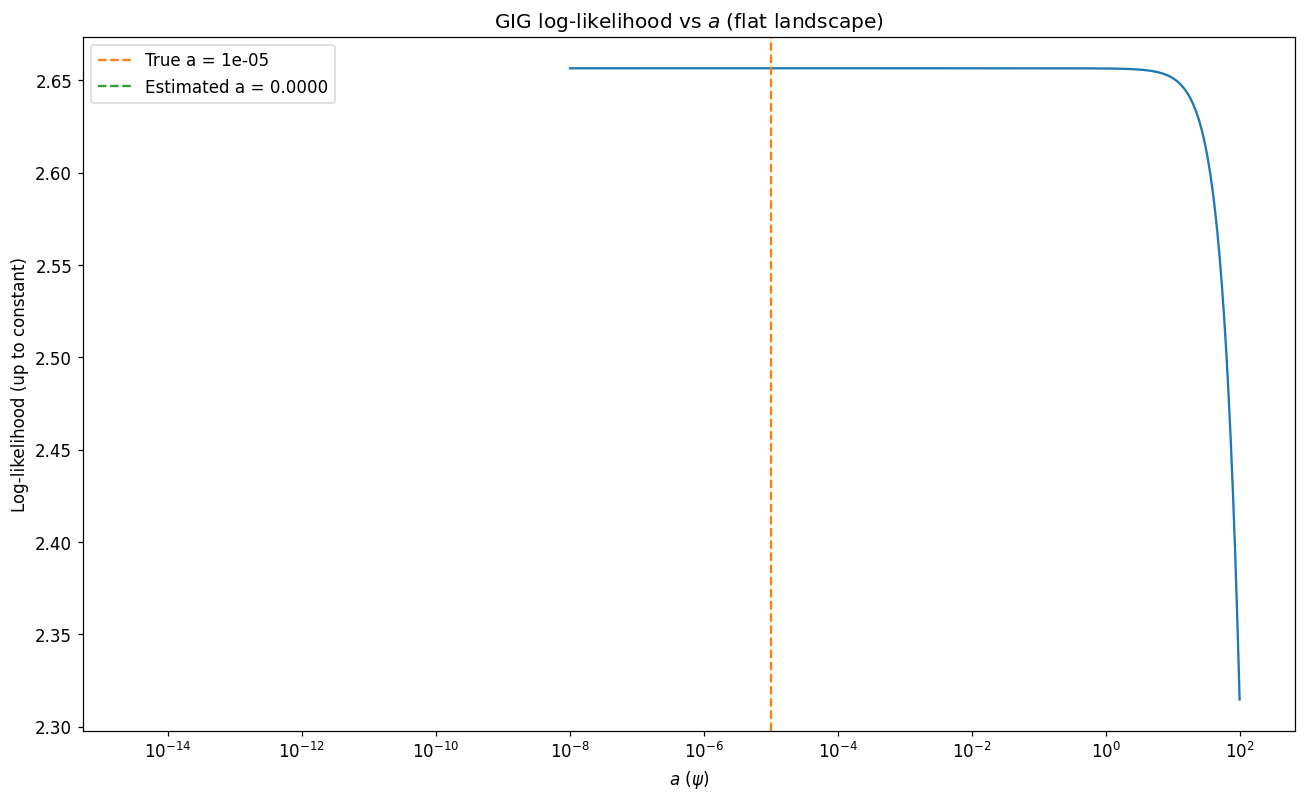

In [3]:
eta_hat = jnp.mean(jax.vmap(GIG.sufficient_statistics)(Y), axis=0)

a_grid = jnp.logspace(-8, 2, 300)

@jax.jit
def loglik_sweep(a_grid, eta_hat):
    def ll_at_a(a_val):
        theta = jnp.array([p_true - 1.0, -b_true / 2.0, -a_val / 2.0])
        return jnp.dot(theta, eta_hat) - GIG._log_partition_from_theta(theta)
    return jax.vmap(ll_at_a)(a_grid)

loglik = loglik_sweep(a_grid, eta_hat)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.plot(np.array(a_grid), np.array(loglik), linewidth=1.5)
ax.axvline(a_true, color='C1', linestyle='--', label=f'True a = {a_true}')
ax.axvline(a_hat, color='C2', linestyle='--', label=f'Estimated a = {a_hat:.4f}')
ax.set_xscale('log')
ax.set_xlabel('$a$ ($\\psi$)')
ax.set_ylabel('Log-likelihood (up to constant)')
ax.set_title('GIG log-likelihood vs $a$ (flat landscape)')
ax.legend()
plt.tight_layout()
plt.show()

## Table 2: Relative Errors of the GH M-step

Start from known 1D GH parameters, compute the exact expectation parameters,
then recover the classical parameters via the M-step formulas.
The normal parameters ($\mu, \gamma, \Sigma$) recover at machine epsilon;
GIG parameters may not, but the Hellinger distance stays small.

In [4]:
d = 1
mu_true = jnp.array([0.2646])
gamma_true = jnp.array([-0.3013])
L_true = jnp.eye(d)
p_gh = 10.0
a_gh = 24.1022
b_gh = 8.4438e-05

joint_true = JointGeneralizedHyperbolic(
    mu=mu_true, gamma=gamma_true, L_Sigma=L_true,
    p=p_gh, a=a_gh, b=b_gh)

# Exact expectation parameters of the subordinator
gig_true_2 = GIG(p=p_gh, a=a_gh, b=b_gh)
gig_eta = gig_true_2.expectation_params()
E_log_Y = float(gig_eta[0])
E_inv_Y = float(gig_eta[1])
E_Y = float(gig_eta[2])

# Exact joint expectation parameters (from theory)
E_X = mu_true + gamma_true * E_Y
E_X_inv_Y = mu_true * E_inv_Y + gamma_true
E_XXT_inv_Y = (jnp.eye(d)
    + jnp.outer(mu_true, mu_true) * E_inv_Y
    + jnp.outer(gamma_true, gamma_true) * E_Y
    + jnp.outer(mu_true, gamma_true)
    + jnp.outer(gamma_true, mu_true))

# M-step: recover normal parameters
mu_rec, gamma_rec, L_rec = JointNormalMixture._mstep_normal_params(
    E_X, E_X_inv_Y, E_XXT_inv_Y, jnp.float64(E_inv_Y), jnp.float64(E_Y))

# M-step: recover GIG parameters
gig_rec = GIG.from_expectation(gig_eta, backend='cpu', verbose=1)

sigma_rec = float(L_rec[0, 0])**2
p_rec = float(gig_rec.p)
a_rec = float(gig_rec.a)
b_rec = float(gig_rec.b)

# Build the recovered joint for Hellinger comparison
joint_recovered = JointGeneralizedHyperbolic(
    mu=mu_rec, gamma=gamma_rec, L_Sigma=L_rec,
    p=gig_rec.p, a=gig_rec.a, b=gig_rec.b)

h2_gh = float(squared_hellinger(joint_true, joint_recovered))

table2 = pd.DataFrame({
    'Parameter': ['mu', 'gamma', 'sigma^2', 'p (lambda)', 'a (psi)', 'b (chi)'],
    'True': [float(mu_true[0]), float(gamma_true[0]), 1.0, p_gh, a_gh, b_gh],
    'Estimated': [float(mu_rec[0]), float(gamma_rec[0]), sigma_rec, p_rec, a_rec, b_rec],
    'Relative Error': [
        rel_err(float(mu_true[0]), float(mu_rec[0])),
        rel_err(float(gamma_true[0]), float(gamma_rec[0])),
        rel_err(1.0, sigma_rec),
        rel_err(p_gh, p_rec),
        rel_err(a_gh, a_rec),
        rel_err(b_gh, b_rec),
    ],
})

print('Table 2: Relative errors of the GH parameters (M-step roundtrip)')
print('=' * 70)
print(table2.to_string(index=False))
print(f'\nSquared Hellinger distance (joint GH): {h2_gh:.4e}')

Bregman multistart [cpu/lbfgs, 15 starts]: NOT converged (0.081s), |grad|=1.44e-10
Table 2: Relative errors of the GH parameters (M-step roundtrip)
 Parameter      True  Estimated  Relative Error
        mu  0.264600   0.264600    2.097927e-16
     gamma -0.301300  -0.301300    5.527164e-16
   sigma^2  1.000000   1.000000    1.000000e-08
p (lambda) 10.000000   9.999995    4.735974e-07
   a (psi) 24.102200  24.102193    2.849273e-07
   b (chi)  0.000084   0.000087    3.436283e-02

Squared Hellinger distance (joint GH): 8.8818e-13


## Table 3: Errors of the GH EM Algorithm

1. Fit a 2D GH distribution to real stock return data via EM → base model
2. For each $p \in \{-10, -8, \ldots, 10\}$: replace $p$ in the base model
   (other parameters unchanged) → "true" model
3. Generate 5000 samples from each "true" model
4. Re-fit via EM (all parameters free)
5. Compare: relative errors of each parameter group + squared Hellinger distance

The key observation: even when $b$ (for $p > 0$) or $a$ (for $p < 0$) has
enormous relative error, $H^2$ stays small — the distributions are close.

In [5]:
import equinox as eqx

returns = pd.read_csv('../data/sp500_returns.csv', index_col=0)
cols = ['AAPL', 'MSFT']
X_real = jnp.array(returns[cols].dropna().values, dtype=jnp.float64)
print(f'Data: {X_real.shape[0]} observations, {X_real.shape[1]} stocks')

model_base = GeneralizedHyperbolic.default_init(X_real)
result_base = model_base.fit(
    X_real, max_iter=200, tol=1e-4,
    regularization='det_sigma_one', verbose=1)
model_base = result_base.model

j = model_base.joint
print(f'\nBase model: p={float(j.p):.4f}, a={float(j.a):.4f}, b={float(j.b):.4f}')

Data: 2552 observations, 2 stocks

  EM Fitting: GeneralizedHyperbolic
  Algorithm    : EM
  Loop         : Python loop
  E-step       : cpu
  M-step       : cpu / newton
  Regularize   : det_sigma_one
  Tolerance    : 1.0e-04
  Max iters    : 200
  Converged after 45 iterations (25.60s), final LL=5.765397

Base model: p=-1.0533, a=1182.5027, b=0.0002


In [6]:
p_values = list(range(-10, 11, 2))
results = []

for p_val in p_values:
    print(f'\np = {p_val:+3d} ', end='', flush=True)

    # Construct "true" model: base model with p replaced
    joint_true = eqx.tree_at(lambda j: j.p, model_base.joint, jnp.float64(p_val))
    model_true = GeneralizedHyperbolic(joint_true)

    # Generate synthetic samples from "true" model
    X_synth = model_true.rvs(5000, seed=p_val + 100)

    # Re-fit via EM (all params free)
    try:
        result2 = model_true.fit(
            X_synth, max_iter=200, tol=1e-4,
            regularization='det_sigma_one', verbose=0)
        model_est = result2.model
        print(f'[refit: {result2.n_iter} iters] ', end='', flush=True)
    except Exception as e:
        print(f'[refit FAILED: {e}]')
        results.append({'p': p_val, 'err_mu': np.nan, 'err_gamma': np.nan,
            'err_Sigma': np.nan, 'err_p': np.nan,
            'err_b': np.nan, 'err_a': np.nan, 'H2': np.nan})
        continue

    jt = model_true.joint
    je = model_est.joint
    err_mu = vec_rel_err(jt.mu, je.mu)
    err_gamma = vec_rel_err(jt.gamma, je.gamma)
    err_Sigma = vec_rel_err(jt.sigma(), je.sigma())
    err_p = rel_err(float(jt.p), float(je.p))
    err_b = rel_err(float(jt.b), float(je.b))
    err_a = rel_err(float(jt.a), float(je.a))
    h2 = float(squared_hellinger(jt, je))

    print(f'H^2={h2:.4e}')
    results.append({'p': p_val, 'err_mu': err_mu, 'err_gamma': err_gamma,
        'err_Sigma': err_Sigma, 'err_p': err_p,
        'err_b': err_b, 'err_a': err_a, 'H2': h2})


p = -10 [refit: 41 iters] H^2=0.0000e+00

p =  -8 [refit: 81 iters] H^2=0.0000e+00

p =  -6 [refit: 64 iters] H^2=1.2826e-03

p =  -4 [refit: 53 iters] H^2=6.1782e-04

p =  -2 [refit: 17 iters] H^2=1.6293e-04

p =  +0 [refit: 22 iters] H^2=5.3086e-04

p =  +2 [refit: 200 iters] H^2=1.0237e-02

p =  +4 [refit: 200 iters] H^2=1.2282e-04

p =  +6 [refit: 200 iters] H^2=1.5865e-03

p =  +8 [refit: 200 iters] H^2=0.0000e+00

p = +10 [refit: 52 iters] H^2=0.0000e+00


In [7]:
df = pd.DataFrame(results)

print('Table 3: Errors of the GH EM algorithm')
print('=' * 100)

fmt = {
    'err_mu': '{:.4f}'.format, 'err_gamma': '{:.4f}'.format,
    'err_Sigma': '{:.4f}'.format, 'err_p': '{:.4f}'.format,
    'err_b': '{:.4e}'.format, 'err_a': '{:.4e}'.format,
    'H2': '{:.4e}'.format,
}
print(df.to_string(index=False, formatters=fmt))

Table 3: Errors of the GH EM algorithm
  p  err_mu err_gamma err_Sigma                                                                                                                                                                                                                                                                                                            err_p      err_b      err_a         H2
-10  0.1147    5.3911    0.0054                                                                                                                                                                                                                                                                                                           0.0000 1.0807e-02 1.0691e-02 0.0000e+00
 -8  0.1732    4.9120    0.0061                                                                                                                                                                                              

### Visualisation

Plot the squared Hellinger distance alongside the max parameter relative error.
The key insight: $H^2$ is bounded and small, even as individual parameter errors explode.

/home/bajie/github/normix/.venv/lib/python3.12/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


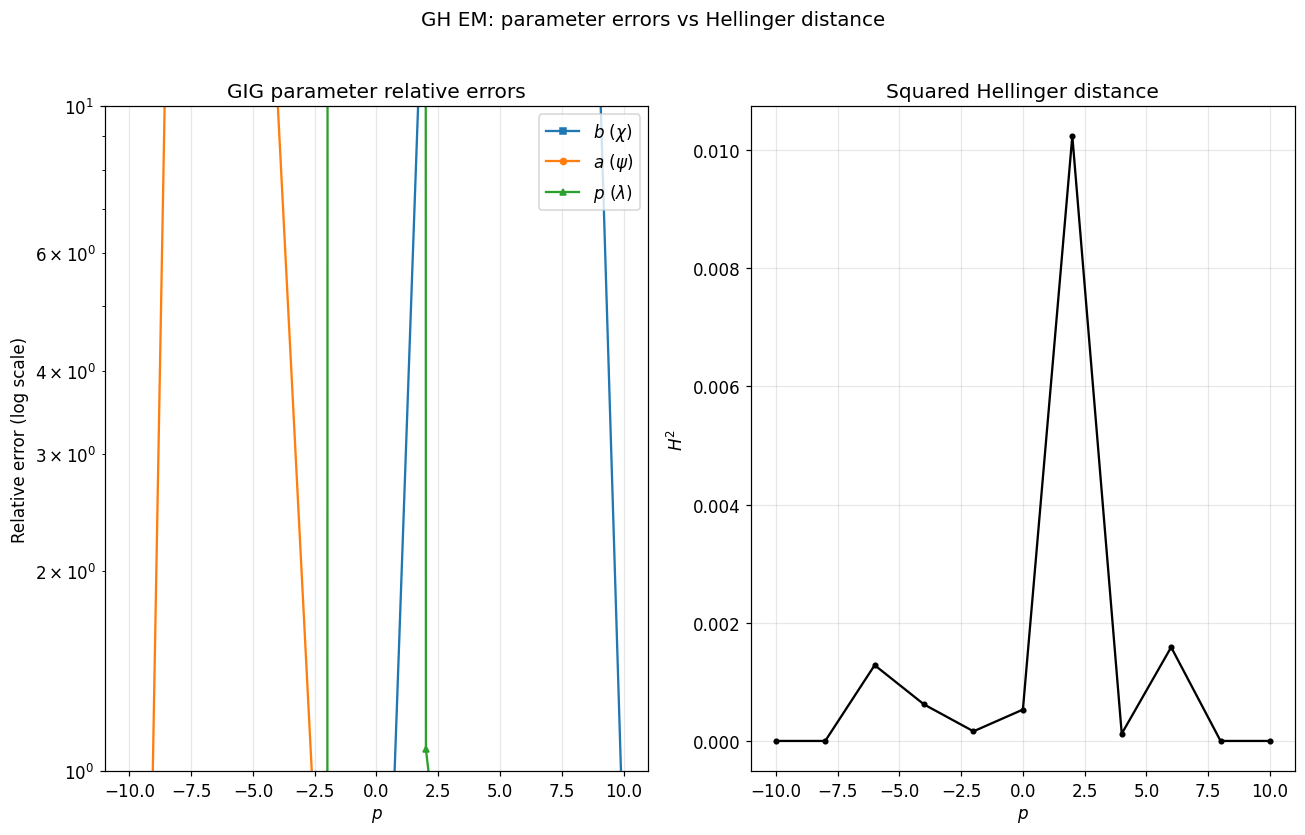

In [8]:
df_plot = df.dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

ax1.semilogy(df_plot['p'], df_plot['err_b'], 's-', label='$b$ ($\\chi$)', markersize=4)
ax1.semilogy(df_plot['p'], df_plot['err_a'], 'o-', label='$a$ ($\\psi$)', markersize=4)
ax1.semilogy(df_plot['p'], df_plot['err_p'], '^-', label='$p$ ($\\lambda$)', markersize=4)
ax1.set_xlabel('$p$')
ax1.set_ylabel('Relative error (log scale)')
ax1.set_title('GIG parameter relative errors')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df_plot['p'], df_plot['H2'], 'k.-', linewidth=1.5, markersize=6)
ax2.set_xlabel('$p$')
ax2.set_ylabel('$H^2$')
ax2.set_title('Squared Hellinger distance')
ax2.grid(True, alpha=0.3)

fig.suptitle('GH EM: parameter errors vs Hellinger distance', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Conclusion

The Hellinger distance is a natural and robust error metric for exponential
family distributions. For the GIG and GH families:

- The log-likelihood surface can be very flat along certain parameter directions,
  making classical relative errors misleading.
- The Hellinger distance, expressible purely via the log-partition function
  $H^2(p, q) = 1 - \exp(\psi(\bar\theta) - \frac{1}{2}[\psi(\theta_p) + \psi(\theta_q)])$,
  captures the actual distributional difference.
- This formula is general for *all* exponential families and is JIT-able, vmap-able,
  and differentiable via JAX.